In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sunpy.time import parse_time

In [3]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [4]:
flares.columns

Index(['start_UTC', 'end_UTC', 'peak_UTC', '4-10 keV', '10-15 keV',
       '15-25 keV', '25-50 keV', '50-84 keV', 'bkg 4-10 keV', 'bkg 10-15 keV',
       'bkg 15-25 keV', 'bkg 25-50 keV', 'bkg 50-84 keV',
       'bkg_baseline_4-10 keV', 'hpc_x_solo', 'hpc_y_solo', 'hpc_x_earth',
       'hpc_y_earth', 'visible_from_earth', 'hgs_lon', 'hgs_lat', 'hgc_lon',
       'hgc_lat', 'solo_position_lat', 'solo_position_lon',
       'solo_position_AU_distance', 'GOES_class_time_of_flare',
       'GOES_flux_time_of_flare', 'att_in', 'flare_id', 'sidelobes_ratio',
       'goes_estimated_min_class', 'goes_estimated_max_class',
       'goes_estimated_mean_class', 'goes_estimated_min_flux',
       'goes_estimated_max_flux', 'goes_estimated_mean_flux',
       'error_with_imaging', 'cpd_filename'],
      dtype='str')

In [5]:
flares.describe()

,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,bkg 15-25 keV,bkg 25-50 keV,bkg 50-84 keV,...,hgc_lat,solo_position_lat,solo_position_lon,solo_position_AU_distance,GOES_flux_time_of_flare,flare_id,sidelobes_ratio,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux
count,3.173000e+04,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,...,30158.000000,31730.000000,31730.000000,31730.000000,31730.000000,3.173000e+04,30157.000000,3.173000e+04,3.173000e+04,3.173000e+04
mean,4.042266e+04,4366.595462,1064.369808,997.268894,611.476269,283.836685,43.116168,54.208635,672.580334,348.002710,...,-2.414099,1.529482,48.452824,0.663088,0.000005,2.374327e+09,0.807669,2.132193e-06,6.160943e-06,3.536346e-06
std,3.472875e+05,24235.709407,13462.245244,4316.640413,2464.908860,34.665112,9.652070,15.182117,73.048764,93.664921,...,20.367051,6.850382,103.411071,0.222971,0.000016,1.076535e+08,0.072850,1.075104e-05,4.380917e-05,2.133953e-05
min,1.076000e+03,49.000000,49.000000,543.000000,199.000000,107.000000,29.000000,37.000000,607.000000,303.000000,...,-87.516180,-16.842773,-179.989967,0.292578,0.000000,2.102140e+09,0.661243,2.394918e-07,3.794765e-07,2.970846e-07
25%,1.727000e+03,167.000000,75.000000,671.000000,367.000000,247.000000,41.000000,49.000000,607.000000,303.000000,...,-16.999350,-3.065243,-20.336599,0.452886,0.000001,2.305140e+09,0.756532,5.113338e-07,9.938114e-07,7.000000e-07
50%,3.199000e+03,335.000000,107.000000,735.000000,367.000000,303.000000,41.000000,49.000000,671.000000,319.000000,...,-8.417625,1.878885,13.741673,0.697295,0.000003,2.405152e+09,0.783636,7.425837e-07,1.533840e-06,1.000000e-06
75%,9.727000e+03,1087.000000,247.000000,799.000000,431.000000,303.000000,45.000000,53.000000,735.000000,367.000000,...,14.985094,6.681559,158.588150,0.871823,0.000004,2.412191e+09,0.831793,1.322663e-06,3.000000e-06,2.000000e-06
max,2.721608e+07,475135.000000,884735.000000,475135.000000,204799.000000,431.000000,123.000000,231.000000,1471.000000,2175.000000,...,89.343905,16.843229,179.993692,1.015069,0.000905,2.601292e+09,0.999958,6.795688e-04,2.988570e-03,1.404400e-03


In [6]:
earth_vis = flares[flares['visible_from_earth']==True]
earth_vis[['goes_estimated_mean_flux', 'GOES_flux_time_of_flare']]

,goes_estimated_mean_flux,GOES_flux_time_of_flare
25,1.000000e-06,8.419415e-07
26,7.000000e-07,5.962394e-07
30,1.000000e-06,8.065577e-07
31,1.000000e-06,3.893343e-06
32,1.000000e-06,6.997967e-07
...,...,...
31542,2.893695e-06,3.045503e-06
31543,5.765014e-06,5.248081e-06
31544,1.705525e-06,2.810757e-06
31550,1.422213e-06,3.000193e-06


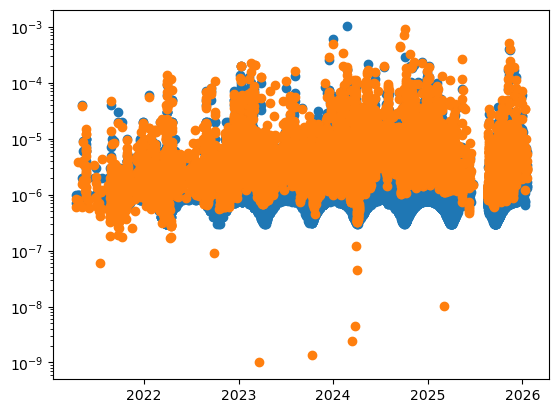

In [13]:
plt.scatter(parse_time(earth_vis['peak_UTC']).datetime, earth_vis['goes_estimated_mean_flux'])
plt.scatter(parse_time(earth_vis['peak_UTC']).datetime, earth_vis['GOES_flux_time_of_flare'])
plt.yscale('log')

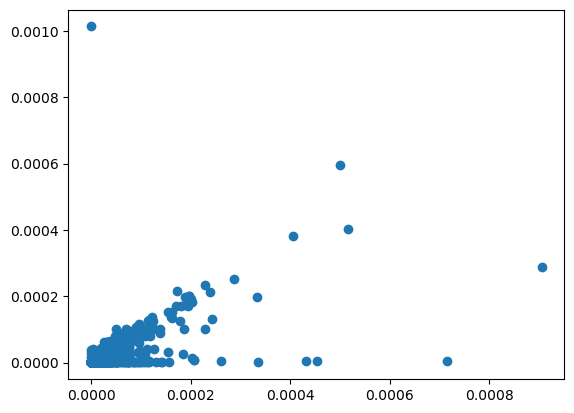

In [14]:
plt.scatter(parse_time(earth_vis['peak_UTC']).datetime, earth_vis['goes_estimated_mean_flux'])
plt.scatter(parse_time(earth_vis['peak_UTC']).datetime, earth_vis['GOES_flux_time_of_flare'])
plt.yscale('log')

In [ ]:
image_err = flares[flares["error_with_imaging"] == True]
image_err
#1572 errored flares (out of 31730)

In [ ]:
x = image_err.loc[0]
parse_time(x['peak_UTC'])

In [ ]:
error_times = parse_time(image_err['peak_UTC']).datetime

In [ ]:
plt.hist(error_times, bins=100)
plt.yscale('log')
plt.ylabel('Frequency of flares with imaging errors')
plt.xlabel('Peak time')

In [ ]:
flares['hgs_lon']

In [ ]:
flares['hgs_lon'].isnull()

In [ ]:
no_hgs_lon = flares[flares['hgs_lon'].isnull()==True]
no_hgs_lon
#1572 flares without location - same number as errored flares, are they the 
#same flares? assume yes

In [ ]:
#compare errored and no location
# for flare in image_err:
#     print(flare.index)
    

In [ ]:
#size distribution - how rare are bigger flares?
flares['goes_estimated_mean_flux'].plot(kind='hist', logy=True, bins=50, label='_nolegend')
plt.xlabel('GOES Estimated Mean Flux (W/m$^2$)')
plt.xscale('log')
#plt.axvspan(10**(-8), 10**(-7), color='lightblue', alpha=0.5, label='A')
plt.axvspan(flares['goes_estimated_mean_flux'].min(), 10**(-6), color='orange', alpha=0.3, label='B')
plt.axvspan(10**(-6), 10**(-5), color='green', alpha=0.3, label='C')
plt.axvspan(10**(-5), 10**(-4), color='red', alpha=0.3, label='M')
plt.axvspan(10**(-4), flares['goes_estimated_mean_flux'].max(), color='purple', alpha=0.3, label='X')
plt.legend()

In [ ]:
#HOW MANY FLARES NOT VISIBLE FROM EARTH
not_earth_vis = flares[flares['visible_from_earth']==False]
not_earth_vis
#14949 flares not visible from Earth (~half)

In [ ]:
#SIZE OF FLARES NOT VISIBLE FROM EARTH
not_earth_vis['goes_estimated_mean_flux'].plot(kind='hist', logy=True, bins=50)
plt.xlabel('GOES Estimated Mean Flux (W/m$^2$)')

In [ ]:
# fig, ax = plt.subplots()

# ax.hist(flares['goes_estimated_mean_flux'], log=True, bins=50, histtype='bar')
# ax.hist(not_earth_vis['goes_estimated_mean_flux'], log=True, bins=50, histtype='bar')

In [ ]:
flares['goes_estimated_mean_class']

In [ ]:
#CLUSTERING IN HGS LONGITUDE
flares['hgc_lon'].plot(kind='hist', bins=100)
plt.xlabel('Heliographic Carrington Longitude (degrees)')

In [ ]:
flares.columns

In [ ]:
#BUTTERFLY DIAGRAM - HGS LAT AGAINST TIME
plt.scatter(parse_time(flares['peak_UTC']).datetime, flares['hgs_lat'], color='goldenrod', label='flare')
plt.ylabel('Heliographic Stonyhurst Latitude (degrees)')
#plt.legend()
plt.xlabel('Peak Time')

In [ ]:
monthly_flares = flares.copy()
monthly_flares['peak_UTC'] = pd.to_datetime(monthly_flares['peak_UTC'])
monthly_flare_counts = monthly_flares.groupby(monthly_flares['peak_UTC'].dt.to_period('M')).size()

In [ ]:
monthly_flare_counts.index=monthly_flare_counts.index.to_timestamp()

In [ ]:
plt.plot(monthly_flare_counts.index, monthly_flare_counts.values, label='_none', color='gold')
plt.vlines(datetime(2024, 10, 1), 0, 1750, color='darkorange', linestyle = 'dashed', label='Peak of solar cycle')
plt.ylabel('Solar flares per month')
plt.legend()